In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd

In [2]:
data=pd.read_csv("housing (1).csv")
data.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
data.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

In [4]:
x=data[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population']]
y=data['Price']

In [5]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=43)

In [6]:
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array([ 719068.42578463, 1574470.82615854, 1151675.49491649, ...,
       1772846.1689582 , 1409290.98168354, 1259035.34157973],
      shape=(1500,))

In [7]:
coeff_df=pd.DataFrame(model.coef_,x.columns,columns=['Coefficient'])
print("Coeffecient\n")
coeff_df

Coeffecient



,Coefficient
Avg. Area Income,21.396594
Avg. Area House Age,165122.772427
Avg. Area Number of Rooms,120428.706297
Avg. Area Number of Bedrooms,978.266339
Area Population,15.111813


In [8]:
from sklearn import metrics
print("Explained Variance Score:",metrics.explained_variance_score(y_test,y_pred))
print("Mean Absolute Error:",metrics.mean_absolute_error(y_test,y_pred))
print("Median Absolute Error:",metrics.median_absolute_error(y_test,y_pred))
print("Mean Squared Error:",metrics.mean_squared_error(y_test,y_pred))
print("Mean Squared Log Error:",metrics.mean_squared_log_error(y_test,y_pred))
print("Root Mean Squared Error:",metrics.root_mean_squared_error(y_test,y_pred))
print("R2_Score:",metrics.r2_score(y_test,y_pred))

Explained Variance Score: 0.921197741112038
Mean Absolute Error: 81288.349824206
Median Absolute Error: 70147.44217971794
Mean Squared Error: 10162508652.684586
Mean Squared Log Error: 0.01119431393341318
Root Mean Squared Error: 100809.26868440513
R2_Score: 0.9211581324845752


In [9]:
import matplotlib.pyplot as plt

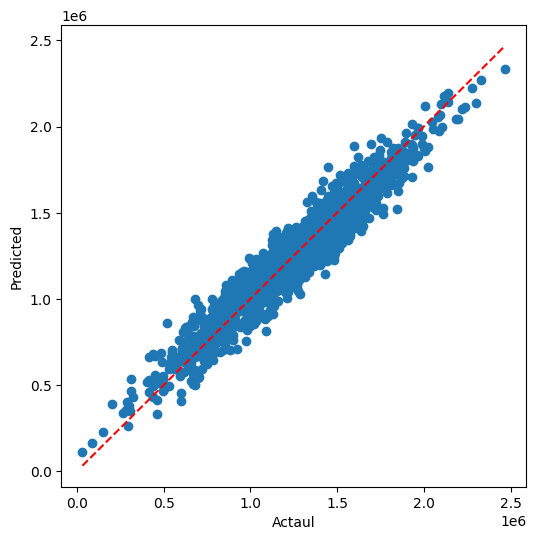

In [16]:
plt.figure(figsize=(6,6))
plt.xlabel("Actaul")
plt.ylabel("Predicted")

plt.scatter(y_test,y_pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')

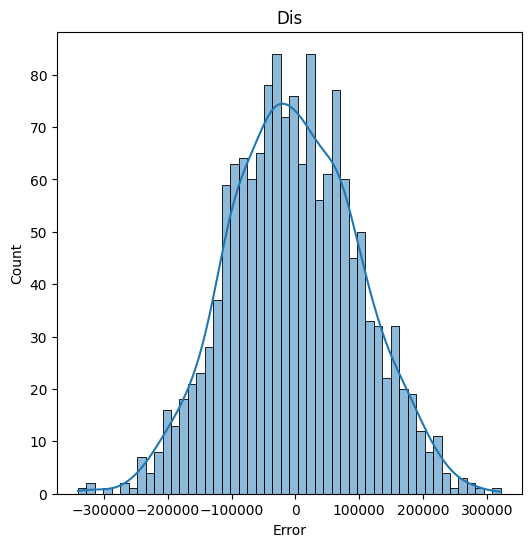

In [14]:
import seaborn as sns
plt.figure(figsize=(6,6))
sns.histplot((y_test-y_pred),kde=True,bins=50)
plt.xlabel("Error")
plt.title("Dis")
plt.show()

In [23]:
dff_comp=pd.DataFrame(model.coef_,x.columns,columns=['Coeffiecient'])
print("Coeefecient\n")
print(dff_comp)
print(model.intercept_)

Coeefecient

                               Coeffiecient
Avg. Area Income                  21.396594
Avg. Area House Age           165122.772427
Avg. Area Number of Rooms     120428.706297
Avg. Area Number of Bedrooms     978.266339
Area Population                   15.111813
-2613591.7278307467


In [28]:
import warnings
warnings.filterwarnings('ignore')
data=[[21.3,165122.77,120428.7,978.26,15.11]]
yp=model.predict(data)
print(round(yp[0]))

[4.17669462e+10]
